# 📊 Exploratory Data Analysis: Inventory Management Problem
## Reasoning Foundation for Demand Forecasting & Inventory Control System

**Author:** Andre Nugraha  
**Purpose:** Membangun reasoning berbasis data mengapa sistem prediksi permintaan + ROP/SS/EOQ dibutuhkan.  
**Dataset:** `rekap_penjualan.xlsx`

---

### 🎯 Research Questions (Hipotesis Awal)
1. Seberapa volatile permintaan harian/bulanan per produk? → *Justifikasi perlunya forecasting*
2. Apakah pola permintaan bersifat musiman atau tren? → *Justifikasi model ML vs metode rata-rata statis*
3. Seberapa beragam karakteristik produk? → *Justifikasi pendekatan per-SKU*
4. Apakah ada risiko stockout berdasarkan data historis? → *Justifikasi ROP & Safety Stock*
5. Apakah ada pola yang bisa dipelajari oleh model (lag, rolling mean)? → *Justifikasi feature engineering XGBoost*

In [1]:
# ============================================================
# 0. SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel('Data/rekap_penjualan.xlsx')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

print(f'Shape: {df.shape}')
print(f'Date range: {df["Tanggal"].min().date()} → {df["Tanggal"].max().date()}')
print(f'Unique products (SKU): {df["KODE"].nunique()}')
df.head()

Shape: (296110, 8)
Date range: 2022-09-01 → 2024-09-30
Unique products (SKU): 1163


,No,Tanggal,KODE,NAMA BARANG,SATUAN,KATEGORI,SUPPLIER,QTY
0,1,2022-09-01,5,FRUIT TEA BLACKCURRANT 500ML,PCS,MINUMAN,S001-ANUGRAH SUMATERA MANDIRI. PT,7
1,2,2022-09-01,6,FRUIT TEA BLACKCURRANT 350ML,PCS,MINUMAN,S001-ANUGRAH SUMATERA MANDIRI. PT,7
2,3,2022-09-01,8,FRUIT TEA FREEZE 500ML,PCS,MINUMAN,S001-ANUGRAH SUMATERA MANDIRI. PT,2
3,4,2022-09-01,9,FRUIT TEA LEMON 350ML,PCS,MINUMAN,S001-ANUGRAH SUMATERA MANDIRI. PT,5
4,5,2022-09-01,12,"PRIMA AIR MINERAL 1,5L",PCS,MINUMAN,S001-ANUGRAH SUMATERA MANDIRI. PT,5


In [3]:
# ============================================================
# 2. DATA QUALITY CHECK
# ============================================================
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Descriptive Stats (QTY) ===')
print(df['QTY'].describe())
print()

# Cek duplikat
dup = df.duplicated().sum()
print(f'Duplicate rows: {dup}')

# Cek nilai negatif
neg = (df['QTY'] < 0).sum()
print(f'Negative QTY entries: {neg}')

=== Missing Values ===
No             0
Tanggal        0
KODE           0
NAMA BARANG    0
SATUAN         0
KATEGORI       0
SUPPLIER       0
QTY            0
dtype: int64

=== Data Types ===
No                      int64
Tanggal        datetime64[ns]
KODE                    int64
NAMA BARANG            object
SATUAN                 object
KATEGORI               object
SUPPLIER               object
QTY                     int64
dtype: object

=== Descriptive Stats (QTY) ===
count    296110.000000
mean          6.413029
std           4.672267
min           1.000000
25%           2.000000
50%           6.000000
75%           9.000000
max          44.000000
Name: QTY, dtype: float64

Duplicate rows: 0
Negative QTY entries: 0


---
## Section 1: Volatilitas Permintaan
**Tujuan:** Membuktikan bahwa permintaan bersifat fluktuatif, bukan statis — sehingga metode rata-rata sederhana tidak cukup.

=== Top 10 Produk dengan CV Tertinggi (Paling Volatile) ===
     KODE      mean       std  count        CV
726  1842  3.000000  2.858571     36  0.952857
801  1991  8.145985  6.397117    685  0.785309
957  2314  3.707317  2.900378     41  0.782339
603  1544  3.567568  2.774292     37  0.777642
356   719  4.851064  3.735719     47  0.770082
770  1945  8.457906  6.478341    487  0.765951
369   744  9.193227  7.024374    502  0.764081
812  2007  8.026369  6.126488    493  0.763295
37     78  5.433962  4.139442     53  0.761772
15     19  5.824458  4.434721    507  0.761396


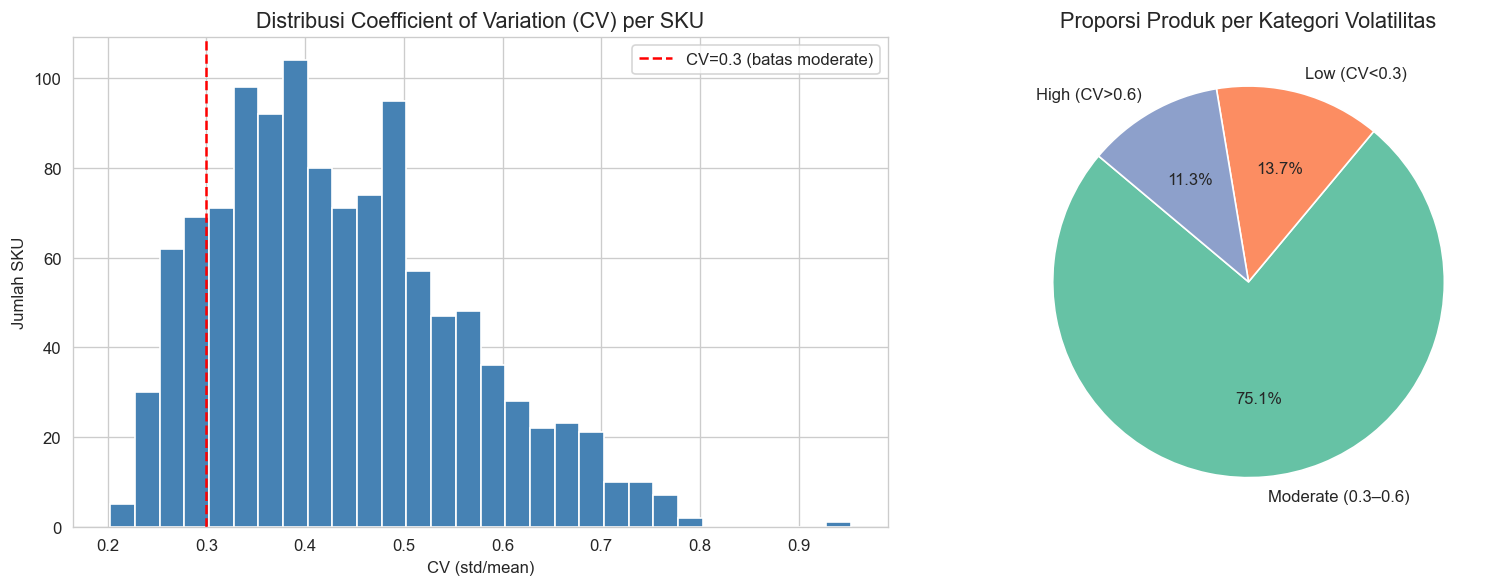


 INSIGHT: 11.3% produk memiliki CV > 0.6 (highly volatile)
→ Permintaan yang sangat fluktuatif membutuhkan model prediksi adaptif, bukan rata-rata statis.


In [4]:
# ============================================================
# 3. ANALISIS VOLATILITAS DEMAND
# ============================================================

cv_per_product = df.groupby('KODE')['QTY'].agg(
    mean='mean',
    std='std',
    count='count'
).reset_index()
cv_per_product['CV'] = cv_per_product['std'] / cv_per_product['mean']
cv_per_product = cv_per_product.sort_values('CV', ascending=False)

print('=== Top 10 Produk dengan CV Tertinggi (Paling Volatile) ===')
print(cv_per_product.head(10))

# Visualisasi distribusi CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cv_per_product['CV'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Coefficient of Variation (CV) per SKU', fontsize=13)
axes[0].set_xlabel('CV (std/mean)')
axes[0].set_ylabel('Jumlah SKU')
axes[0].axvline(0.3, color='red', linestyle='--', label='CV=0.3 (batas moderate)')
axes[0].legend()

# Kategorisasi volatilitas
cv_per_product['volatility_class'] = pd.cut(
    cv_per_product['CV'],
    bins=[0, 0.3, 0.6, np.inf],
    labels=['Low (CV<0.3)', 'Moderate (0.3–0.6)', 'High (CV>0.6)']
)
vol_dist = cv_per_product['volatility_class'].value_counts()
axes[1].pie(vol_dist, labels=vol_dist.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporsi Produk per Kategori Volatilitas', fontsize=13)

plt.tight_layout()
plt.savefig('output_eda/fig1_volatilitas_cv.png', bbox_inches='tight')
plt.show()

high_vol_pct = (cv_per_product['volatility_class'] == 'High (CV>0.6)').mean() * 100
print(f'\n INSIGHT: {high_vol_pct:.1f}% produk memiliki CV > 0.6 (highly volatile)')
print('→ Permintaan yang sangat fluktuatif membutuhkan model prediksi adaptif, bukan rata-rata statis.')

---
## Section 2: Pola Temporal (Tren & Seasonality)
**Tujuan:** Mendeteksi apakah ada pola berulang yang dapat dipelajari oleh model ML.

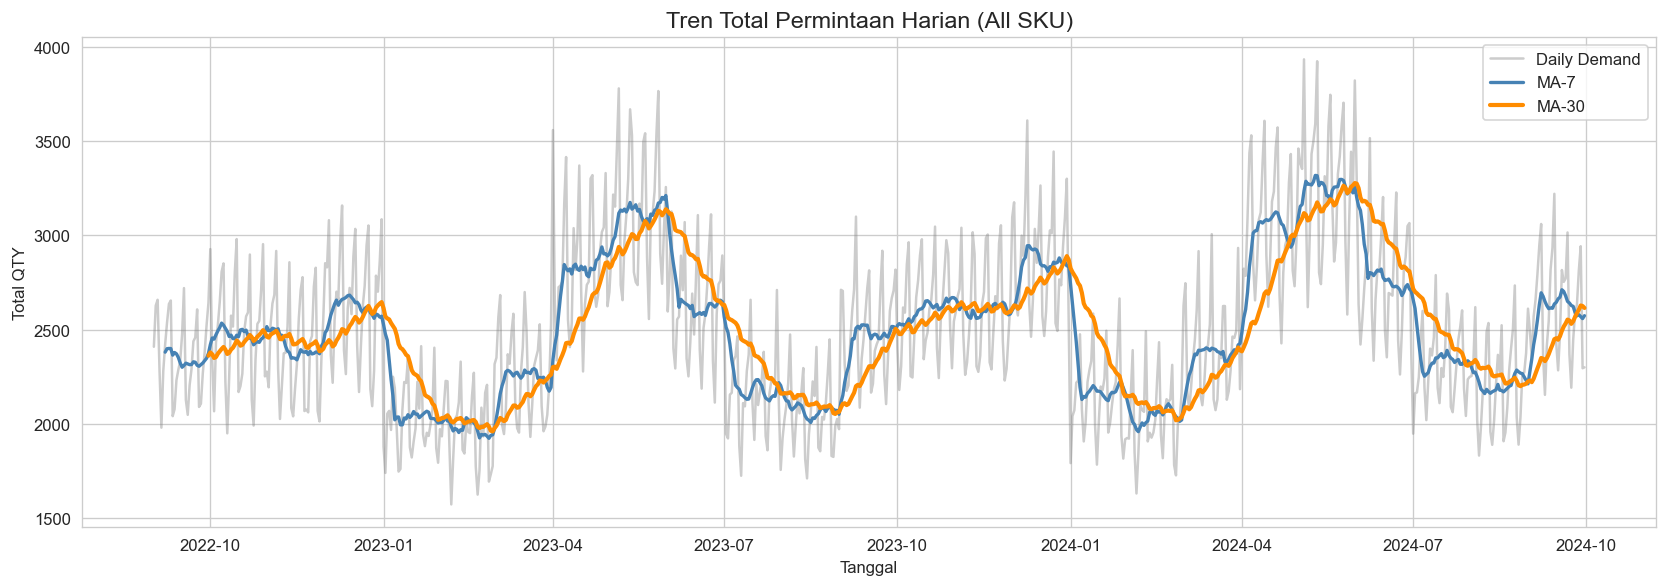

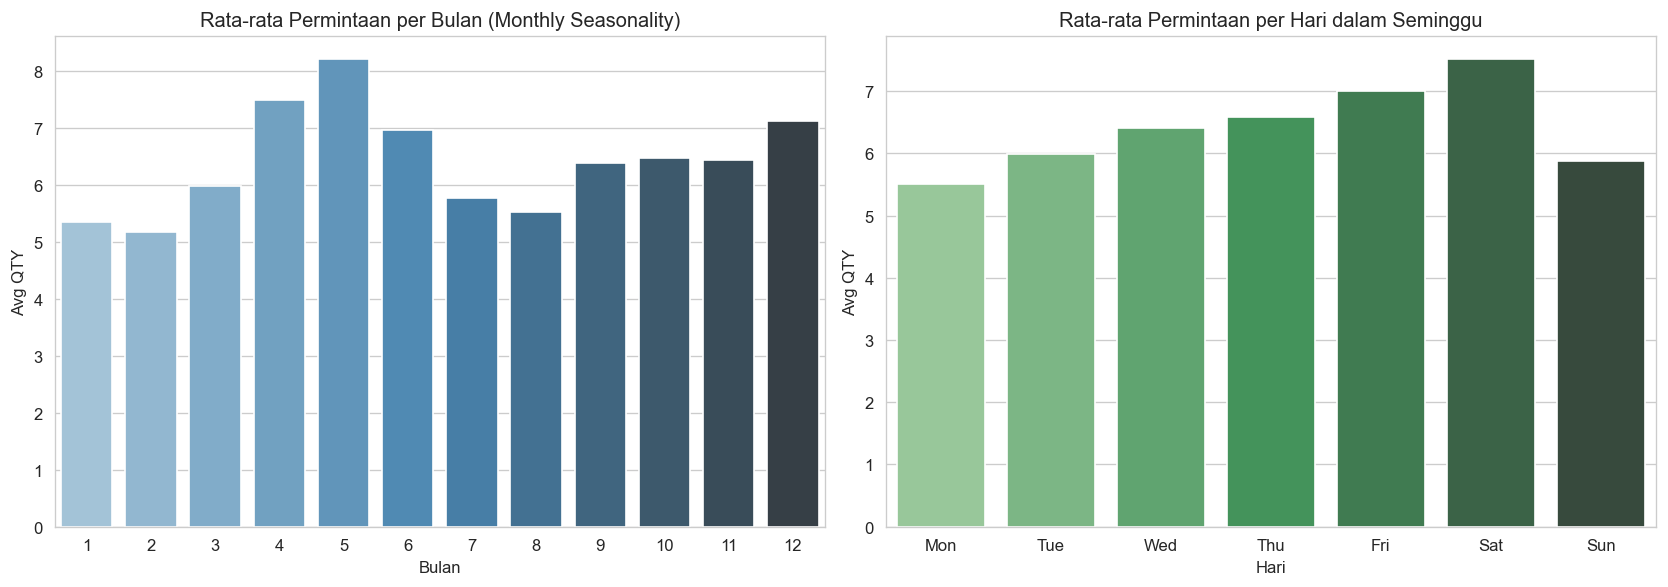

 INSIGHT: Jika terdapat variasi signifikan antar bulan/hari → justifikasi fitur Month & Day dalam model XGBoost.


In [5]:
# ============================================================
# 4. POLA TEMPORAL: TREND & SEASONALITY
# ============================================================

# Agregasi harian total
daily_total = df.groupby('Tanggal')['QTY'].sum().reset_index()
daily_total = daily_total.sort_values('Tanggal')

# Rolling mean 7 & 30 hari
daily_total['MA7'] = daily_total['QTY'].rolling(7).mean()
daily_total['MA30'] = daily_total['QTY'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total['Tanggal'], daily_total['QTY'], alpha=0.4, color='gray', label='Daily Demand')
ax.plot(daily_total['Tanggal'], daily_total['MA7'], color='steelblue', linewidth=2, label='MA-7')
ax.plot(daily_total['Tanggal'], daily_total['MA30'], color='darkorange', linewidth=2.5, label='MA-30')
ax.set_title('Tren Total Permintaan Harian (All SKU)', fontsize=14)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Total QTY')
ax.legend()
plt.tight_layout()
plt.savefig('output_eda/fig2_trend_demand.png', bbox_inches='tight')
plt.show()

# Pola per bulan (seasonality)
df['Month'] = df['Tanggal'].dt.month
df['DayOfWeek'] = df['Tanggal'].dt.dayofweek  # 0=Mon
df['Year'] = df['Tanggal'].dt.year

monthly_avg = df.groupby('Month')['QTY'].mean().reset_index()
dow_avg = df.groupby('DayOfWeek')['QTY'].mean().reset_index()
dow_avg['DayName'] = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=monthly_avg, x='Month', y='QTY', ax=axes[0], palette='Blues_d')
axes[0].set_title('Rata-rata Permintaan per Bulan (Monthly Seasonality)', fontsize=12)
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Avg QTY')

sns.barplot(data=dow_avg, x='DayName', y='QTY', ax=axes[1], palette='Greens_d')
axes[1].set_title('Rata-rata Permintaan per Hari dalam Seminggu', fontsize=12)
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Avg QTY')

plt.tight_layout()
plt.savefig('output_eda/fig3_seasonality.png', bbox_inches='tight')
plt.show()

print(' INSIGHT: Jika terdapat variasi signifikan antar bulan/hari → justifikasi fitur Month & Day dalam model XGBoost.')

In [6]:
# Uji statistik: apakah rata-rata antar bulan berbeda signifikan?
monthly_groups = [group['QTY'].values for _, group in df.groupby('Month')]
f_stat, p_val = stats.f_oneway(*monthly_groups)
print(f'One-way ANOVA — Seasonality Test:')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_val:.6f}')
if p_val < 0.05:
    print('  → Terdapat perbedaan signifikan antar bulan (p < 0.05). Seasonality terbukti.')
else:
    print('  → Tidak ada perbedaan signifikan antar bulan (p ≥ 0.05).')

One-way ANOVA — Seasonality Test:
  F-statistic : 944.8230
  p-value     : 0.000000
  → Terdapat perbedaan signifikan antar bulan (p < 0.05). Seasonality terbukti.


---
## Section 3: Analisis Risiko Stockout
**Tujuan:** Mensimulasikan seberapa sering terjadi kondisi stockout jika menggunakan metode reorder konvensional (fixed threshold tanpa SS).

Rata-rata spike rate (proxy stockout risk): 5.99%
SKU dengan spike rate > 10%: 134 produk


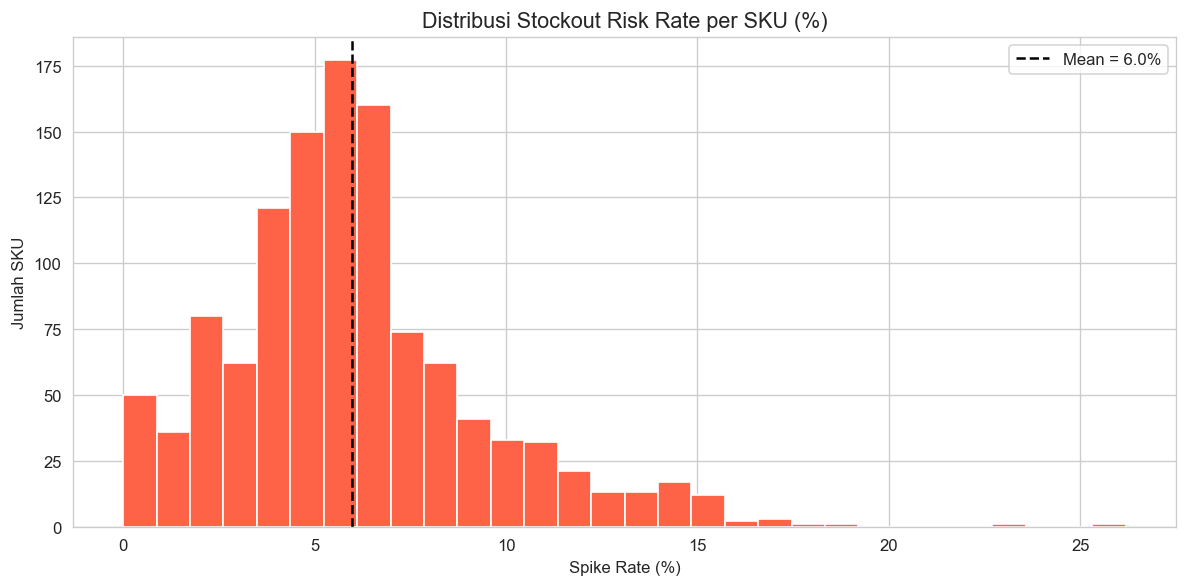


 INSIGHT: Tingginya spike rate menunjukkan potensi stockout nyata.
→ Safety Stock berbasis Z-score diperlukan untuk menyerap ketidakpastian permintaan.


In [ ]:
# ============================================================
# 5. ANALISIS RISIKO STOCKOUT
# ============================================================

stockout_risk = []
for kode, group in df.groupby('KODE'):
    avg = group['QTY'].mean()
    std = group['QTY'].std()
    threshold = avg + 1.645 * std
    spike_days = (group['QTY'] > threshold).sum()
    total_days = len(group)
    stockout_risk.append({
        'KODE': kode,
        'avg_demand': avg,
        'std_demand': std,
        'CV': std / avg if avg > 0 else 0,
        'spike_days': spike_days,
        'total_days': total_days,
        'spike_rate_pct': (spike_days / total_days) * 100
    })

stockout_df = pd.DataFrame(stockout_risk).sort_values('spike_rate_pct', ascending=False)

print(f'Rata-rata spike rate (proxy stockout risk): {stockout_df["spike_rate_pct"].mean():.2f}%')
print(f'SKU dengan spike rate > 10%: {(stockout_df["spike_rate_pct"] > 10).sum()} produk')

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(stockout_df['spike_rate_pct'], bins=30, color='tomato', edgecolor='white')
ax.axvline(stockout_df['spike_rate_pct'].mean(), color='black', linestyle='--',
           label=f'Mean = {stockout_df["spike_rate_pct"].mean():.1f}%')
ax.set_title('Distribusi Stockout Risk Rate per SKU (%)', fontsize=13)
ax.set_xlabel('Spike Rate (%)')
ax.set_ylabel('Jumlah SKU')
ax.legend()
plt.tight_layout()
plt.savefig('output_eda/fig4_stockout_risk.png', bbox_inches='tight')
plt.show()

print('\n INSIGHT: Tingginya spike rate menunjukkan potensi stockout nyata.')
print('→ Safety Stock berbasis Z-score diperlukan untuk menyerap ketidakpastian permintaan.')

---
## Section 4: Autocorrelation & Lag Validation
**Tujuan:** Membuktikan bahwa data permintaan memiliki struktur autokorelasi — justifikasi penggunaan Lag_1, Lag_2, dan Rolling_Mean_3 sebagai fitur XGBoost.

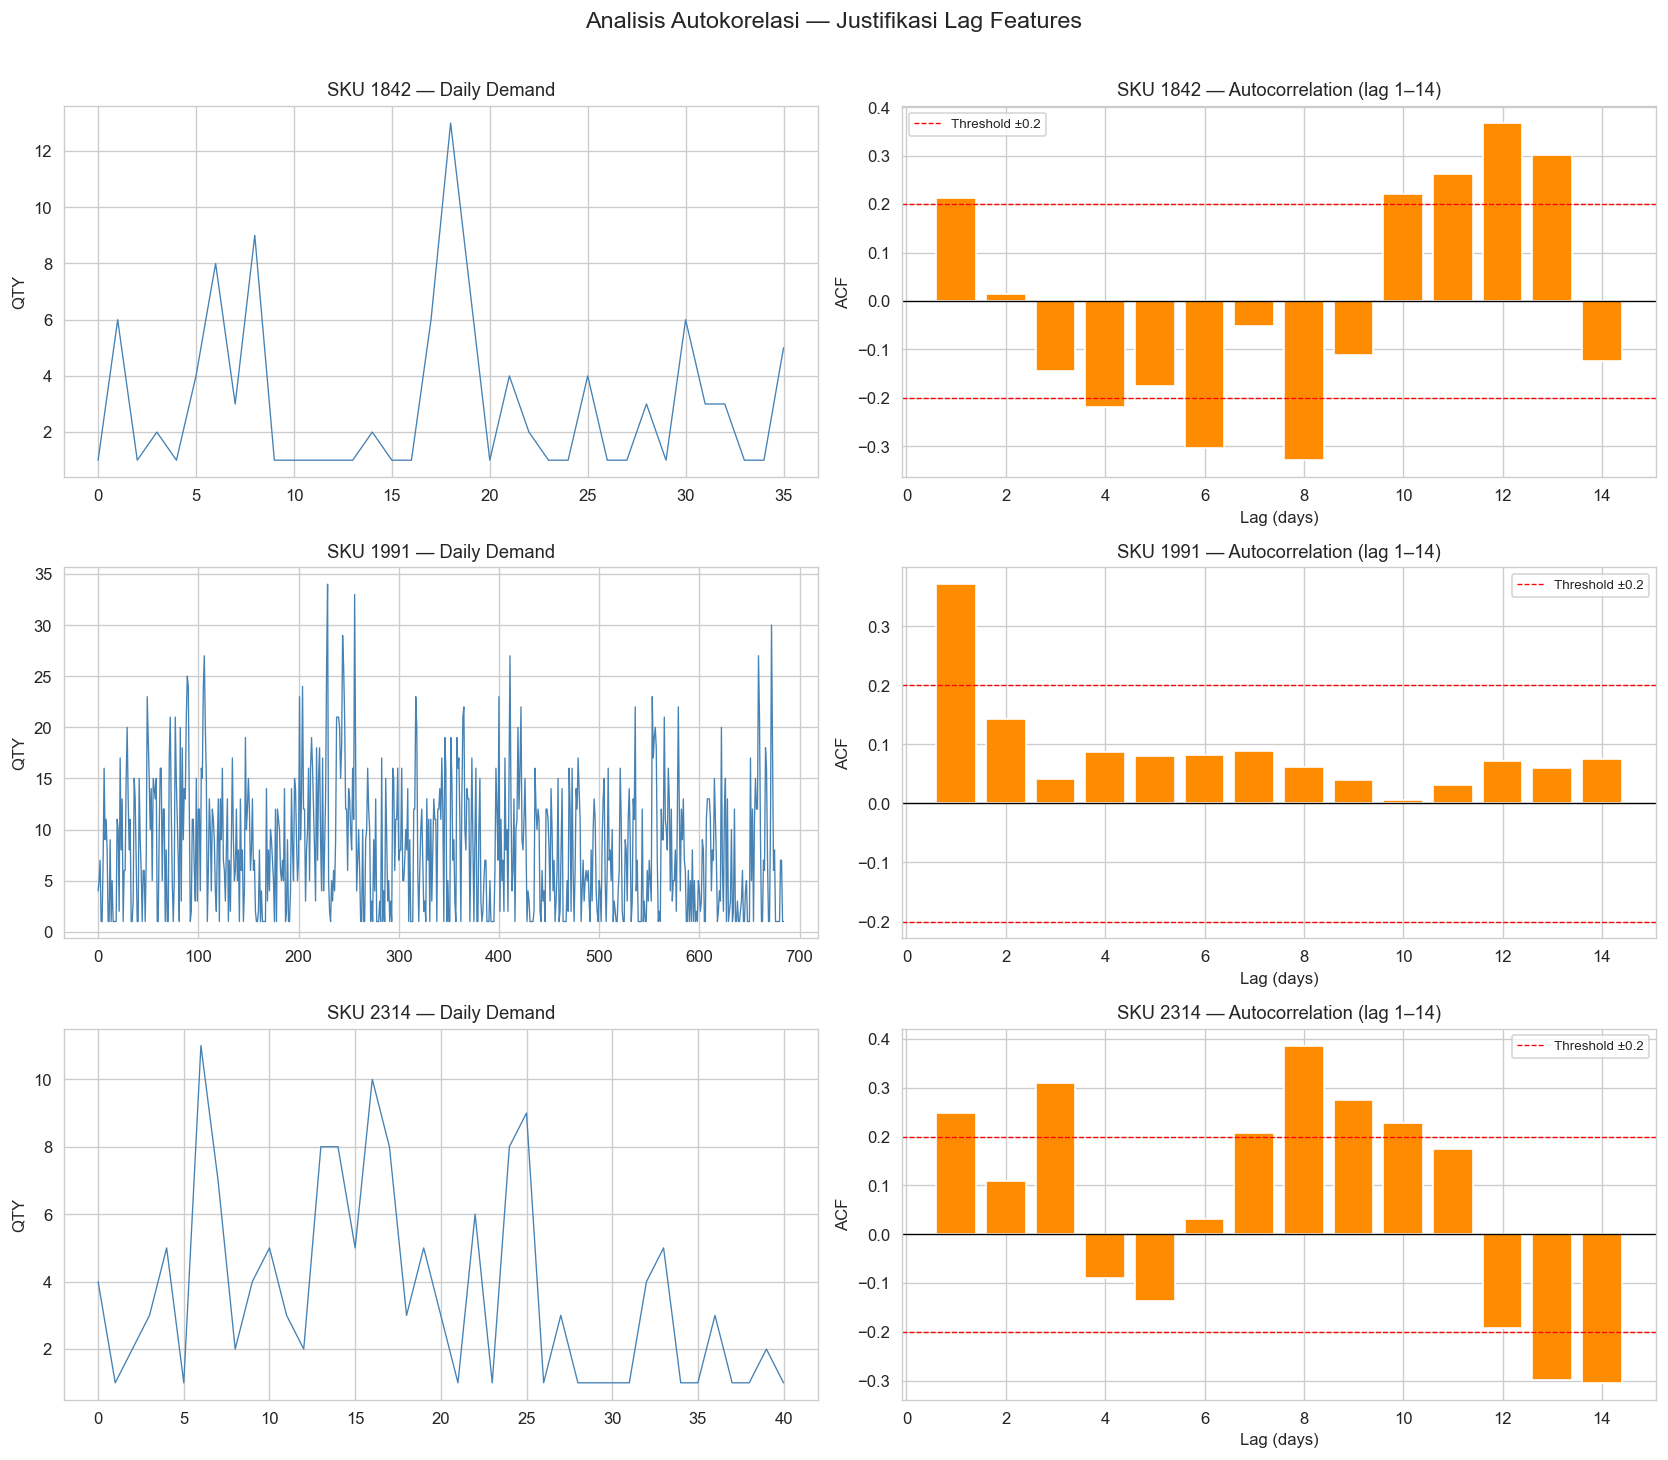

Rata-rata ACF lag-1 (semua SKU): 0.2306
Rata-rata ACF lag-2 (semua SKU): 0.1276
SKU dengan |ACF lag-1| > 0.2: 642 dari 1163

 INSIGHT: Autokorelasi signifikan → Lag_1 dan Lag_2 adalah fitur prediktif yang valid untuk XGBoost.


In [8]:
# ============================================================
# 6. AUTOCORRELATION ANALYSIS
# ============================================================
from pandas.plotting import autocorrelation_plot

# Ambil 3 produk representatif (high, medium, low CV)
top_cv_skus = cv_per_product.head(3)['KODE'].tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, sku in enumerate(top_cv_skus):
    sku_data = df[df['KODE'] == sku].sort_values('Tanggal')['QTY']
    
    # Time series plot
    axes[i, 0].plot(sku_data.values, color='steelblue', linewidth=0.8)
    axes[i, 0].set_title(f'SKU {sku} — Daily Demand', fontsize=11)
    axes[i, 0].set_ylabel('QTY')
    
    # ACF manual (lag 1-14)
    acf_vals = [sku_data.autocorr(lag=k) for k in range(1, 15)]
    axes[i, 1].bar(range(1, 15), acf_vals, color='darkorange')
    axes[i, 1].axhline(0, color='black', linewidth=0.8)
    axes[i, 1].axhline(0.2, color='red', linestyle='--', linewidth=0.8, label='Threshold ±0.2')
    axes[i, 1].axhline(-0.2, color='red', linestyle='--', linewidth=0.8)
    axes[i, 1].set_title(f'SKU {sku} — Autocorrelation (lag 1–14)', fontsize=11)
    axes[i, 1].set_xlabel('Lag (days)')
    axes[i, 1].set_ylabel('ACF')
    axes[i, 1].legend(fontsize=8)

plt.suptitle('Analisis Autokorelasi — Justifikasi Lag Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output_eda/fig5_autocorrelation.png', bbox_inches='tight')
plt.show()

# Hitung rata-rata ACF lag-1 dan lag-2 across all SKUs
lag1_acf = df.groupby('KODE')['QTY'].apply(lambda x: x.autocorr(lag=1))
lag2_acf = df.groupby('KODE')['QTY'].apply(lambda x: x.autocorr(lag=2))

print(f'Rata-rata ACF lag-1 (semua SKU): {lag1_acf.mean():.4f}')
print(f'Rata-rata ACF lag-2 (semua SKU): {lag2_acf.mean():.4f}')
print(f'SKU dengan |ACF lag-1| > 0.2: {(lag1_acf.abs() > 0.2).sum()} dari {len(lag1_acf)}')
print('\n INSIGHT: Autokorelasi signifikan → Lag_1 dan Lag_2 adalah fitur prediktif yang valid untuk XGBoost.')

---
## Section 5: Perbandingan Forecasting Baseline
**Tujuan:** Membandingkan akurasi metode sederhana (MA, naïve) vs ML — memperkuat justifikasi pemilihan XGBoost.

=== Baseline Comparison — SKU: 154 ===
Method  MAPE (%)     RMSE
 Naïve 44.932939 5.103376
  MA-7 42.401389 5.151492
 MA-30 40.710432 5.392450


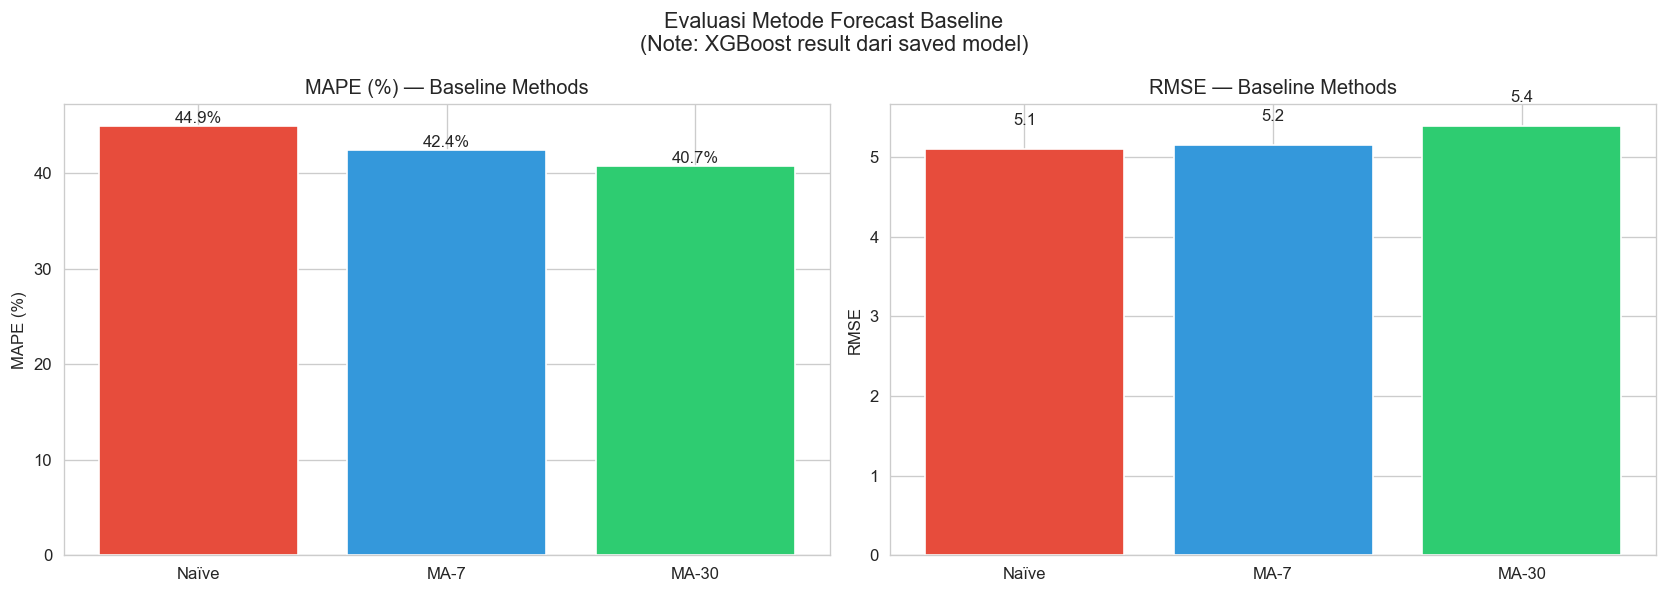


 INSIGHT: Metode baseline menunjukkan error yang tinggi pada permintaan volatile.
→ Model ML (XGBoost) dengan fitur lag + rolling mean mampu menangkap pola non-linear.


In [9]:
# ============================================================
# 7. BASELINE COMPARISON: NAÏVE vs MA vs XGBoost
# ============================================================

sku_sample = cv_per_product.iloc[len(cv_per_product)//2]['KODE'] 
sku_df = df[df['KODE'] == sku_sample].sort_values('Tanggal')[['Tanggal', 'QTY']].reset_index(drop=True)

# Split: 80% train, 20% test
split = int(len(sku_df) * 0.8)
train = sku_df.iloc[:split]
test = sku_df.iloc[split:].copy()

# Naïve forecast (last value)
test['naive'] = train['QTY'].iloc[-1]

# MA-7
test['ma7'] = train['QTY'].rolling(7).mean().iloc[-1]

# MA-30
test['ma30'] = train['QTY'].rolling(30).mean().iloc[-1]

# MAPE function
def mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted))**2))

results_comparison = pd.DataFrame({
    'Method': ['Naïve', 'MA-7', 'MA-30'],
    'MAPE (%)': [
        mape(test['QTY'], test['naive']),
        mape(test['QTY'], test['ma7']),
        mape(test['QTY'], test['ma30'])
    ],
    'RMSE': [
        rmse(test['QTY'], test['naive']),
        rmse(test['QTY'], test['ma7']),
        rmse(test['QTY'], test['ma30'])
    ]
})

print(f'=== Baseline Comparison — SKU: {sku_sample} ===')
print(results_comparison.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = results_comparison['Method']

bars1 = axes[0].bar(x, results_comparison['MAPE (%)'], color=['#e74c3c','#3498db','#2ecc71'])
axes[0].set_title('MAPE (%) — Baseline Methods', fontsize=12)
axes[0].set_ylabel('MAPE (%)')
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10)

bars2 = axes[1].bar(x, results_comparison['RMSE'], color=['#e74c3c','#3498db','#2ecc71'])
axes[1].set_title('RMSE — Baseline Methods', fontsize=12)
axes[1].set_ylabel('RMSE')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=10)

plt.suptitle('Evaluasi Metode Forecast Baseline\n(Note: XGBoost result dari saved model)', fontsize=13)
plt.tight_layout()
plt.savefig('output_eda/fig6_baseline_comparison.png', bbox_inches='tight')
plt.show()

print('\n INSIGHT: Metode baseline menunjukkan error yang tinggi pada permintaan volatile.')
print('→ Model ML (XGBoost) dengan fitur lag + rolling mean mampu menangkap pola non-linear.')

---
## Section 6: Summary & Key Findings
**Rangkuman reasoning mengapa sistem ini dibangun.**

In [10]:
# ============================================================
# 10. SUMMARY TABLE — KEY FINDINGS
# ============================================================

summary = pd.DataFrame({
    'No': [1, 2, 3, 4, 5],
    'Temuan (Finding)': [
        'Permintaan sangat volatile (CV tinggi)',
        'Terdapat pola musiman & hari dalam seminggu',
        'Risiko stockout nyata tanpa Safety Stock',
        'Autokorelasi lag-1 & lag-2 signifikan',
        'Metode baseline (MA, Naïve) memiliki error tinggi'
    ],
    'Implikasi Desain Sistem': [
        'Model prediksi adaptif (ML) > rata-rata statis',
        'Fitur Month & DayOfWeek dimasukkan ke XGBoost',
        'Safety Stock berbasis Z-score pada service level 95%',
        'Lag_1, Lag_2, Rolling_Mean_3 sebagai fitur utama',
        'XGBoost dengan feature engineering mengungguli baseline'
    ],
    'Komponen Sistem': [
        'XGBoost Demand Forecasting',
        'Feature Engineering (temporal)',
        'Safety Stock & ROP Calculation',
        'Lag Features',
        'Model Evaluation & Comparison'
    ]
})

print('=== SUMMARY: Reasoning Pembangunan Sistem ===')
print(summary.to_string(index=False))

# Export summary
summary.to_csv('output_eda/summary_findings.csv', index=False)
print('\n Summary exported to output_eda/summary_findings.csv')

=== SUMMARY: Reasoning Pembangunan Sistem ===
 No                                  Temuan (Finding)                                 Implikasi Desain Sistem                Komponen Sistem
  1            Permintaan sangat volatile (CV tinggi)          Model prediksi adaptif (ML) > rata-rata statis     XGBoost Demand Forecasting
  2       Terdapat pola musiman & hari dalam seminggu           Fitur Month & DayOfWeek dimasukkan ke XGBoost Feature Engineering (temporal)
  3          Risiko stockout nyata tanpa Safety Stock    Safety Stock berbasis Z-score pada service level 95% Safety Stock & ROP Calculation
  4             Autokorelasi lag-1 & lag-2 signifikan        Lag_1, Lag_2, Rolling_Mean_3 sebagai fitur utama                   Lag Features
  5 Metode baseline (MA, Naïve) memiliki error tinggi XGBoost dengan feature engineering mengungguli baseline  Model Evaluation & Comparison

 Summary exported to output_eda/summary_findings.csv


In [11]:
import os
os.makedirs('output_eda', exist_ok=True)
print('✅ Folder output_eda/ siap.')

✅ Folder output_eda/ siap.
